In [ ]:
## Import necessary libraries here (You can add libraries you want to use here)
from skimage.util import img_as_float
from skimage import io, color
from skimage import draw
import matplotlib.pyplot as plt
import argparse, time
import math, copy
import numpy as np
import scipy.io
import cv2
from PIL import Image, ImageDraw
from google.colab.patches import cv2_imshow
import plotly.graph_objects as go
from PIL import Image, ImageDraw
from google.colab.patches import cv2_imshow
from sklearn.mixture import GaussianMixture as gmm

In [ ]:
def show_image(img, scale=1.0):
    plt.figure(figsize=scale* plt.figaspect(1))
    plt.imshow(img, interpolation='nearest')
    plt.gray() 
    plt.axis('off')
    plt.show()



# Part 1: SLIC Superpixels (50 Points)

## Overview

Superpixel algorithms group pixels into perceptually meaningful regions while respecting potential object contours, and thereby can replace the rigid pixel grid structure. Due to the reduced complexity, superpixels are becoming popular for various computer vision applications, e.g., multiclass object segmentation, depth estimation, human pose estimation, and object localization.

In this problem, you will implement a simple superpixel algorithm called Simple Linear Iterative Clustering (SLIC) that clusters pixels in the five-dimensional color and pixel coordinate space (e.g., r, g, b, x, y). The algorithm starts with a collection of K cluster centers initialized at an equally sampled regular grid on the image of N pixels. For each cluster, you define for a localized window 2S x 2S centered at the cluster center, where S = sqrt(N/K) is the roughly the space between the seed cluster centers. Then, you check whether the pixel within the 2S x 2S local window should be assigned to the cluster center or not (by comparing the distance in 5D space to the cluster center). Once you loop through all the clusters, you can update the cluster center by averaging over the cluster members. Iterate the pixel-to-cluster assignment process till convergence or maximum iterations reached.

Reference Paper: http://www.kev-smith.com/papers/SMITH_TPAMI12.pdf

You can refer to the following slide covered in Lecture_17_Segmentation.pptx here: https://drive.google.com/file/d/1bRmNBXgK1_kWcY-nhw_As5fP10aRhuDC/view?usp=share_link






## Data
**WARNING: Colab deletes all files everytime runtime is disconnected. Make sure to re-download the inputs when it happens.**

In [ ]:
# Download Data -- run this cell only one time per runtime
!gdown 1jbg2VMZ9yAJMHQNRCTgqZM1PyQRtcPyV
!unzip "/content/Part1_SLIC.zip" -d "/content/"

Downloading...
From: https://drive.google.com/uc?id=1jbg2VMZ9yAJMHQNRCTgqZM1PyQRtcPyV
To: /content/Part1_SLIC.zip
100% 6.19M/6.19M [00:00<00:00, 62.3MB/s]
Archive:  /content/Part1_SLIC.zip
   creating: /content/Part1_SLIC/
  inflating: /content/Part1_SLIC/.DS_Store  
  inflating: /content/__MACOSX/Part1_SLIC/._.DS_Store  
   creating: /content/Part1_SLIC/sample_data/
   creating: /content/Part1_SLIC/BSD_data/
  inflating: /content/Part1_SLIC/sample_data/.DS_Store  
  inflating: /content/__MACOSX/Part1_SLIC/sample_data/._.DS_Store  
   creating: /content/Part1_SLIC/sample_data/images/
  inflating: /content/__MACOSX/Part1_SLIC/sample_data/._images  
   creating: /content/Part1_SLIC/sample_data/groundTruth/
  inflating: /content/__MACOSX/Part1_SLIC/sample_data/._groundTruth  
  inflating: /content/Part1_SLIC/BSD_data/.DS_Store  
  inflating: /content/__MACOSX/Part1_SLIC/BSD_data/._.DS_Store  
   creating: /content/Part1_SLIC/BSD_data/images/
   creating: /content/Part1_SLIC/BSD_data/groun

## Helper Functions:

### Code (15 pts)

In [ ]:

# A class to initialize the super pixels, of the form - [l,a,b,h,w].
class SuperPixel(object):

    def __init__(self, l=0, a=0, b=0, h=0, w=0):
        self.update(l, a, b, h, w)
        self.pixels = []

    def update(self, l, a, b, h, w):
        self.l = l
        self.a = a
        self.b = b
        self.h = h
        self.w = w

# Function which returns an object of class SuperPixel
def make_SuperPixel(h, w,img):
    return SuperPixel(img[h,w][0],img[h,w][1],img[h,w][2], h, w)

def display_clusters(img, clusters):
    image = np.copy(img)
    for c in clusters:
        for p in c.pixels:
            image[p[0],p[1]][0] = c.l
            image[p[0],p[1]][1] = c.a
            image[p[0],p[1]][2] = c.b
        image[c.h, c.w][0] = 0
        image[c.h, c.w][1] = 0
        image[c.h, c.w][2] = 0
    rgb_arr = color.lab2rgb(image) 
    show_image(rgb_arr)

In [ ]:
# Functions for Simple Linear Iterative Clustering (SLIC)

def initialize_cluster_centers(S, image, img_h, img_w, clusters):
    #### Write your code here ####
    # To Do: Initialize "clusters" by sampling pixels at an equally sampled regular grid (distanced by S)
    # on the image of N pixels. N = img_h X img_w. Hint: clusters.append(make_superPixel(h, w, image)) to create each cluster/super-pixel.
    h = S // 2
    w = S // 2
    while h < img_h:
        while w < img_w:
          clusters.append(make_SuperPixel(h, w,image))
          w= w+S
        w = S // 2
        h =  S + h
    return clusters

def cluster_gradient(h,w,img_h,img_w,image):
    if w + 1 >= img_w:
      w = img_w - 2
    if h + 1 >= img_h:
      h =img_h - 2
    gradient = (image[h+1,w+1][0] - image[h,w][0])+(image[h + 1,w + 1][1] - image[h,w][1])+(image[h + 1,w + 1][2] - image[h,w][2])
    return gradient

def relocate_cluster_center_at_lowgrad(clusters, image):
    #### Write your code here ####
    # To Do:
    # for each cluster c, reassign cluster to the pixel having smallest gradient value.
    # Step 1: compute gradient wrt cluster-center c.h, c.w in 3X3 neighborhood of cluster center.
    # Step 2: Similarly, compute gradient for each pixel in 3X3 spatial neighborhood of cluster c.
    # Step 3. Reassign cluster-center to the pixel (x,y) having the lowest gradient. 
    # Hint: c.update(img[x,y][0], img[h,w][1], img[x,y][2], x, y)
    for i in clusters:
      minimum_gradient = cluster_gradient(i.h,i.w,img_h,img_w,image)
      minimum_h,minimum_w = i.h,i.w
      for j in range(-1,2):
         H = i.h + j
         for k in range(-1,2):
            W = i.w + k
            new_cluster_grad = cluster_gradient(H,W,image.shape[0],image.shape[1],image)
            if new_cluster_grad<minimum_gradient:
              minimum_h,minimum_w = H,W
              grad = new_cluster_grad
    i.update(image[minimum_h,minimum_w][0],image[minimum_h,minimum_w][1],image[minimum_h,minimum_w][2],minimum_h,minimum_w)
    return None

def assign_cluster(clusters, S, image, img_h, img_w, cluster_tag, dis,m):
    #### Write your code here ####
    # To Do: Compare each pixel to cluster center within 2S pixel distance and assign to nearest cluster using the "distance metric"
    # (involving both color and spatial dimensions of pixel and cluster, 
    # Hints: 
    # 1. use "dis" matrix for comparing distances.
    # 2. You can use c.pixels.append((h, w)) to keep track of cluster-assignments.
  for i in clusters:
    for h in range(i.h-2*S,i.h+2*S):
      if h<0 or h>=img_h: continue
      for w in range(i.w-2*S,i.w+2*S):
          if w<0 or w>=img_w: continue
          l,a,b = image[h,w]
          distance_color = math.sqrt(math.pow(l-i.l,2)+math.pow(a-i.a,2)+math.pow(b-i.b,2))
          distance_spatial = math.sqrt(math.pow(h-i.h,2)+math.pow(w-i.w,2))
          dist = distance_color + (distance_spatial*m/S)
          if dist < dis[h,w]:
            if (h,w) not in cluster_tag:
              cluster_tag[(h,w)] = i
              i.pixels.append((h,w))
            else:
              cluster_tag[(h,w)].pixels.remove((h,w))
              cluster_tag[(h,w)] = i
              i.pixels.append((h,w))
            dis[h,w] = dist
  return None


def update_clusters(clusters):
    #### Write your code here ####
   
    # To Do: For each cluster, update the cluster center with mean of the pixels assigned (c.pixels)
  for i in clusters:
    H = W = count = 0
    for pix in i.pixels:
      H = H + pix[0]
      W = W + pix[1]
      count = count + 1
      H_mean = H//count
      W_mean = W//count
      i.update(image[H_mean,W_mean][0],image[H_mean,W_mean][1],image[H_mean,W_mean][2],H_mean,W_mean)
  return None
  
def compute_res_error(old_clusters, new_clusters):
    #### Write your code here ####    
  error = []
  # error = Compute L1 distance between previous cluster-centres and new cluster centers.
  for i in range(len(old_clusters)):
    error.append(np.abs(new_clusters[i].h-old_clusters[i].h)+np.abs(new_clusters[i].w-old_clusters[i].w))
    mean_error = np.mean(error)
  return mean_error

def slic_algorithm(S, image, img_h, img_w, clusters, cluster_tag, dis,m):

# Initialize cluster centers on pixel grid in steps S
  clusters = initialize_cluster_centers(S, image, img_h, img_w, clusters)
  # Move centers to position in 3x3 window with smallest gradient.
  relocate_cluster_center_at_lowgrad(clusters, image)
  # You can play around with these hyper-params.
  res_err = 123456789.0 # init residual_error with a very large value (choose as per your u
  threshold = 1 # tune this
  while(res_err >= threshold):
    assign_cluster(clusters, S, image, img_h, img_w, cluster_tag, dis,m)
    old_clusters = copy.deepcopy(clusters)
    update_clusters(clusters)
    res_err = compute_res_error(old_clusters, clusters)
    if res_err<threshold:
      break
  print("residual error",res_err)
  return clusters 


In [ ]:
# Main Block:

img_path = "/content/Part1_SLIC/BSD_data/images/10081.jpg"

# Load image and convert it from an unsigned 8-bit integer to a floating point data type.
image = img_as_float(io.imread(img_path))
# convert RGB to LAB
image = color.rgb2lab(image)
img_h = image.shape[0] #  Height
img_w = image.shape[1] #  Width

# k: Number of clusters/superpixels.
k = 64
m=1
N = img_h * img_w  # Total pixels in the image
S = int(math.sqrt(N /k)) # Average size of each superpixel

clusters = []
cluster_tag = {} # cluster_tag should contain cluster-assignment for pixel h,w. For example, cluster_tag[(h, w)] = c
dis = np.full((img_h, img_w), np.inf) # Distance bwteen pixels and cluster is initialized as infinity at the beginning.
list_duration=[]
sum=0
for i in range(10):
  start_time= time.time()
  clusters = slic_algorithm(S, image, img_h, img_w, clusters, cluster_tag,dis,m)
  stop_time = time.time()
  duration = stop_time-start_time
  sum=sum+duration
  list_duration.append(duration)
  print("Time for iteration", i, duration)
avg=sum/10
print("mean run time is:",avg,"s")





0.7857142857142857
Time for iteration 0 139.68726420402527
0.4928571428571429
Time for iteration 1 14.116103172302246
0.20476190476190476
Time for iteration 2 20.44293522834778
0.12857142857142856
Time for iteration 3 28.15312123298645
0.12571428571428572
Time for iteration 4 33.083555698394775
0.11428571428571428
Time for iteration 5 39.55114531517029
0.08163265306122448
Time for iteration 6 46.05878019332886
0.04642857142857143
Time for iteration 7 53.69114089012146
0.03968253968253968
Time for iteration 8 58.66532516479492
0.03142857142857143
Time for iteration 9 65.19726538658142
mean run time is: 49.864663648605344 s


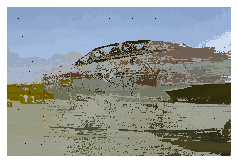

In [ ]:
#k=64
display_clusters(image,clusters)

In [ ]:
# Main Block:

img_path = "/content/Part1_SLIC/BSD_data/images/10081.jpg"

# Load image and convert it from an unsigned 8-bit integer to a floating point data type.
image = img_as_float(io.imread(img_path))
# convert RGB to LAB
image = color.rgb2lab(image)
img_h = image.shape[0] #  Height
img_w = image.shape[1] #  Width

# k: Number of clusters/superpixels.
k = 256
m=1
N = img_h * img_w  # Total pixels in the image
S = int(math.sqrt(N /k)) # Average size of each superpixel

clusters = []
cluster_tag = {} # cluster_tag should contain cluster-assignment for pixel h,w. For example, cluster_tag[(h, w)] = c
dis = np.full((img_h, img_w), np.inf) # Distance bwteen pixels and cluster is initialized as infinity at the beginning.
list_duration=[]
sum1=0
for i in range(10):
  start_time= time.time()
  clusters = slic_algorithm(S, image, img_h, img_w, clusters, cluster_tag,dis,m)
  stop_time = time.time()
  duration = stop_time-start_time
  sum1=sum1+duration
  list_duration.append(duration)
  print("Time for iteration", i, duration)
avg1=sum1/10
print("mean run time is:",avg1,"s")

residual error 0.9961538461538462
Time for iteration 0 69.67854857444763
residual error 0.475
Time for iteration 1 14.956759929656982
residual error 0.18974358974358974
Time for iteration 2 21.56943106651306
residual error 0.08557692307692308
Time for iteration 3 31.251109838485718
residual error 0.057692307692307696
Time for iteration 4 35.01178860664368
residual error 0.021794871794871794
Time for iteration 5 41.79960107803345
residual error 0.015384615384615385
Time for iteration 6 48.399890661239624
residual error 0.010096153846153847
Time for iteration 7 58.0762939453125
residual error 0.0038461538461538464
Time for iteration 8 63.041818618774414
residual error 0.0007692307692307692
Time for iteration 9 79.32230496406555
mean run time is: 46.310754728317264 s


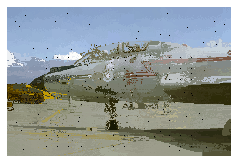

In [ ]:
#K=256
display_clusters(image,clusters)

In [ ]:
# Main Block:

img_path = "/content/Part1_SLIC/BSD_data/images/10081.jpg"

# Load image and convert it from an unsigned 8-bit integer to a floating point data type.
image = img_as_float(io.imread(img_path))
# convert RGB to LAB
image = color.rgb2lab(image)
img_h = image.shape[0] #  Height
img_w = image.shape[1] #  Width

# k: Number of clusters/superpixels.
k = 1024
m=1
N = img_h * img_w  # Total pixels in the image
S = int(math.sqrt(N /k)) # Average size of each superpixel

clusters = []
cluster_tag = {} # cluster_tag should contain cluster-assignment for pixel h,w. For example, cluster_tag[(h, w)] = c
dis = np.full((img_h, img_w), np.inf) # Distance bwteen pixels and cluster is initialized as infinity at the beginning.
list_duration=[]
sum2=0
for i in range(10):
  start_time= time.time()
  clusters = slic_algorithm(S, image, img_h, img_w, clusters, cluster_tag,dis,m)
  stop_time = time.time()
  duration = stop_time-start_time
  sum2=sum2+duration
  list_duration.append(duration)
  print("Time for iteration", i, duration)
avg2=sum2/10
print("mean run time is:",avg2,"s")

residual error 0.6824074074074075
Time for iteration 0 46.59053063392639
residual error 0.24444444444444444
Time for iteration 1 16.27014398574829
residual error 0.09537037037037037
Time for iteration 2 23.71195936203003
residual error 0.046296296296296294
Time for iteration 3 31.78580117225647
residual error 0.02185185185185185
Time for iteration 4 42.371788024902344
residual error 0.011882716049382716
Time for iteration 5 47.13571310043335
residual error 0.004629629629629629
Time for iteration 6 54.83977913856506
residual error 0.0019675925925925924
Time for iteration 7 62.93388509750366
residual error 0.0015432098765432098
Time for iteration 8 73.94267177581787
residual error 0.000925925925925926
Time for iteration 9 78.78671932220459
mean run time is: 47.836899161338806 s


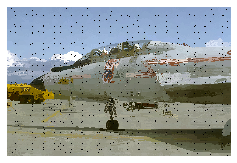

In [ ]:
#k=1024
display_clusters(image,clusters)

In [ ]:
# Main Block:

img_path = "/content/Part1_SLIC/BSD_data/images/10081.jpg"

# Load image and convert it from an unsigned 8-bit integer to a floating point data type.
image = img_as_float(io.imread(img_path))
# convert RGB to LAB
image = color.rgb2lab(image)
img_h = image.shape[0] #  Height
img_w = image.shape[1] #  Width

# k: Number of clusters/superpixels.
k = 256
m=1
N = img_h * img_w  # Total pixels in the image
S = int(math.sqrt(N /k)) # Average size of each superpixel

clusters = []
cluster_tag = {} # cluster_tag should contain cluster-assignment for pixel h,w. For example, cluster_tag[(h, w)] = c
dis = np.full((img_h, img_w), np.inf) # Distance bwteen pixels and cluster is initialized as infinity at the beginning.
list_duration=[]
sum1=0
for i in range(10):
  start_time= time.time()
  clusters = slic_algorithm(S, image, img_h, img_w, clusters, cluster_tag,dis,m)
  stop_time = time.time()
  duration = stop_time-start_time
  sum=sum+duration
  list_duration.append(duration)
  print("Time for iteration", i, duration)
avg1=sum1/10
print("mean run time is:",avg1,"s")

residual error 0.7461538461538462
Time for iteration 0 66.60535931587219
residual error 0.24615384615384617
Time for iteration 1 16.140522956848145
residual error 0.16794871794871793
Time for iteration 2 21.729410886764526
residual error 0.1
Time for iteration 3 29.44627070426941
residual error 0.06153846153846154
Time for iteration 4 35.424721002578735
residual error 0.046153846153846156
Time for iteration 5 42.550005197525024
residual error 0.026923076923076925
Time for iteration 6 50.57691240310669
residual error 0.015384615384615385
Time for iteration 7 57.01296949386597
residual error 0.012393162393162393
Time for iteration 8 63.08745622634888
residual error 0.0034615384615384616
Time for iteration 9 71.55018758773804
mean run time is: 0.0 s


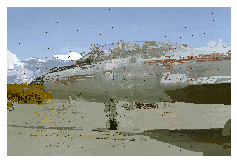

In [ ]:
#color weight 2 times and spatial weight 1 #K=256
display_clusters(image,clusters)

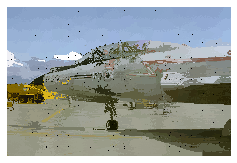

In [ ]:
#color weight 1 times and spatial weight 2 #K=256
display_clusters(image,clusters)

In [ ]:
# Main Block:

# img_path = "/content/Part1_SLIC/BSD_data/images/14085.jpg"
img_path= "/content/Part1_SLIC/BSD_data/images/14092.jpg"
# img_path = "/content/Part1_SLIC/BSD_data/images/15011.jpg"
# img_path = "/content/Part1_SLIC/BSD_data/images/15062.jpg"
# img_path= "/content/Part1_SLIC/BSD_data/images/16004.jpg"
# img_path = "/content/Part1_SLIC/BSD_data/images/16068.jpg"
# img_path = "/content/Part1_SLIC/BSD_data/images/17067.jpg"
# img_path = "/content/Part1_SLIC/BSD_data/images/20069.jpg"
# img_path = "/content/Part1_SLIC/BSD_data/images/2018.jpg"
# Load image and convert it from an unsigned 8-bit integer to a floating point data type.
image= img_as_float(io.imread(img_path))
# image_3 = img_as_float(io.imread(img_path_3))
# image_4 = img_as_float(io.imread(img_path_4))
# image_5 = img_as_float(io.imread(img_path_5))
# image_6 = img_as_float(io.imread(img_path_6))
# image_7 = img_as_float(io.imread(img_path_7))
# image_8 = img_as_float(io.imread(img_path_8))
# image_9 = img_as_float(io.imread(img_path_9))
# image_10 = img_as_float(io.imread(img_path_10))
# convert RGB to LAB
image = color.rgb2lab(image)
img_h = image.shape[0] #  Height
img_w= image.shape[1] #  Width


# k: Number of clusters/superpixels.
k = 1024
m=1
N = img_h * img_w  # Total pixels in the image
S = int(math.sqrt(N /k)) # Average size of each superpixel

clusters = []
cluster_tag = {} # cluster_tag should contain cluster-assignment for pixel h,w. For example, cluster_tag[(h, w)] = c
dis = np.full((img_h, img_w), np.inf) # Distance bwteen pixels and cluster is initialized as infinity at the beginning.
list_duration=[]
sum1=00000.0
for i in range(10):
  start_time= time.time()
  clusters = slic_algorithm(S, image, img_h, img_w, clusters, cluster_tag,dis,m)
  stop_time = time.time()
  duration = stop_time-start_time
  sum1=sum1+duration
  list_duration.append(duration)
  print("Time for iteration", i, duration)
avg1=sum1/10
print("mean run time is:",avg1,"s")

residual error 0.9416666666666667
Time for iteration 0 47.522528648376465
residual error 0.3638888888888889
Time for iteration 1 15.996129989624023
residual error 0.17839506172839506
Time for iteration 2 23.974527597427368
residual error 0.09375
Time for iteration 3 31.5104718208313
residual error 0.05648148148148148
Time for iteration 4 39.39245057106018
residual error 0.02947530864197531
Time for iteration 5 48.894266843795776
residual error 0.01746031746031746
Time for iteration 6 55.44718837738037
residual error 0.009375
Time for iteration 7 62.714205503463745
residual error 0.00360082304526749
Time for iteration 8 70.75807857513428
residual error 0.0024074074074074076
Time for iteration 9 81.97545886039734
mean run time is: 47.818530678749084 s


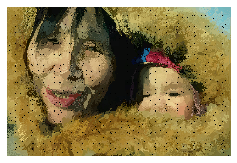

47.22869896888733


In [ ]:
#BSD Image2
display_clusters(image,clusters)
print(avg1)

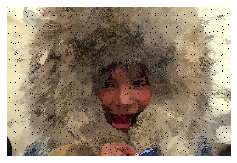

47.818530678749084


In [ ]:
#BSD Image3
display_clusters(image,clusters)
print(avg1)

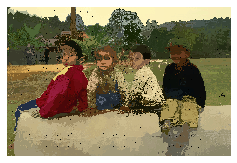

45.657478713989256


In [ ]:
#BSD Image4
display_clusters(image,clusters)
print(avg1)

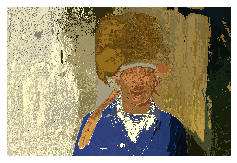

In [ ]:
#BSD Image5
display_clusters(image,clusters)

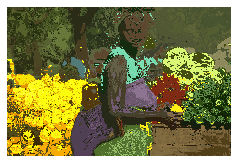

In [ ]:
#BSD Image6
display_clusters(image,clusters)

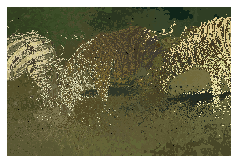

In [ ]:
#BSD Image7
display_clusters(image,clusters)

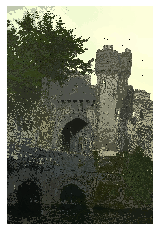

53.01397459506988


In [ ]:
#BSD Image8
display_clusters(image,clusters)
print(avg1)
Iter8=avg1

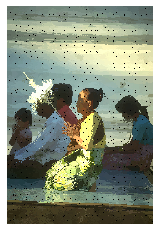

46.09211375713348


In [ ]:
#BSD Image9
display_clusters(image,clusters)
print(avg1)


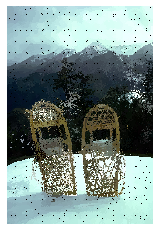

47.137881231307986


In [ ]:
#BSD Image10
display_clusters(image,clusters)
print(avg1)

### Write-up (35 pts)
* a) [5 points] Explain your distance function for measuring the similarity between a pixel and cluster in the 5D space.
* b) [5 points] Choose one image, try three different weights on the color and spatial feature and show the three segmentation results. Describe what you observe.
* c) [5 points] Choose one image, show the error (1) at the initialization and (2) at convergence. Note: error - distance to cluster center in the 5D space.
* d) [10 points] Choose one image and show three superpixel results with different number of K, e.g., 64, 256, 1024 and run time for each K.
* e)  [10 points] Run your algorithms on the subset (50 images) of Berkeley Segmentation Dataset (BSD) with K = 64, 256 and 1024 and report averaged run-time per image for the BSD.


#Write-up for Q1

## a) In the algorithm, K superpixel cluster centers $C_{k}=[l_{k}, a_{k}, b_{k}, x_{k}, y_{k}]$ are chosen with at regular grid intervals $S$. Since the spatial extent of any superpixel is approximately S²(the approximate area of a super-pixel), it is safely assumed that pixels that are associated with this cluster center lie within a $2S×2S$ area around the superpixel center on the $xy$ plane. The normalized distance measure $dist$ to be used in the 5D space is defined as :
## $dist = distance_{color} +(m/S)*distance_{spatial}$

## Where:
## $distance_{color} = \sqrt{(l_{k}-l_{i})^2+(a_{k}-a_{i})^2+(b_{k}-b_{i})^2} $

## $distance_{spatial}=\sqrt{(x_{k}-x_{i})^2+(y_{k}-y_{i})}^2$

## $dist$ is the sum of the l,a,b distance ($dist_{color})$ and the $x, y$ plane distance $dist_{spatial}$ normalized by the grid interval $S$. A variable m is introduced in Dₛ allowing us to control the compactness of a superpixel. The greater the value of m, the more compact the cluster. This value can be in the range [1,20]. For the implemetation I have selected $m=1$.
 
## b) The chosen image was 10081.jpg and $k=256$. The following was the outputs:
  * ### For Equal weights for color and spatial:

   ![picture](https://drive.google.com/uc?id=1sAh9xz_k4QNvVAnnuOrxX0KqMGXLVfMz)

  * ### For Spatial Weight 2 time and Color weight 1 time the following was output:

  ![picture](https://drive.google.com/uc?id=1qvLBoXD_9Co2H4czpttF289ZZ7ns8-_k)

  * ### For Color Weight 2 times and Spatial weight 1:

  ![picture](https://drive.google.com/uc?id=1GGmKJoGJX7Z63A1VN-yT6Kde64Sb3wT-)

## c) From the bsd dataset I have used 10081.jpg image, with $k=64$ and error that was initialized before running the code was $error= 123456789.0$. The the following output was observed:

* ### Output picture

  ![picture](https://drive.google.com/uc?id=1MJel6sB_74WMrcFmG0jce77kbFkFk-7O)

* ### Error at each of 10 iterations:

  ![picture](https://drive.google.com/uc?id=1R6L5AsEcopje83dY8QwAEPmLEF5iEia0)

### In the above image values after iterations are error values at each iteration. Note that for 1st iteration the value of error is printed at the top that is $ 0.7857142........$

### d) I have chosen 10081.jpg from the BSD data and iterated it 10 times for each K value:

* ### $k=64$:


  ### mean run time for 10 iterations for $K=64$:- 49.86s

![picture](https://drive.google.com/uc?id=1MJel6sB_74WMrcFmG0jce77kbFkFk-7O)


* ### $k=256$:


  ### mean run time for 10 iterations for $K=256$:- 47.3s

![picture](https://drive.google.com/uc?id=1uNyf90nGphegRz6TvucoHNmGpZADHmbT)


* ### $k=1024$:


  ### mean run time for 10 iterations for $K=1024$:- 46.3s

![picture](https://drive.google.com/uc?id=178uiJ1SQLVup28SwsXDA2hugGE0rZrET)

### Therefore the average of these 3 $K$ value is : 47.8s

## e) Runtimes
### Frst 10 images from BSD data set were used 10081.jpg-2018.jpg
 *  ### For K=64  average run time was: 50.8s
 *  ### For K=256 Average runtime was: 47.45s
 *  ### For K=1024 Average runtime was: 40.5s


### Extra Credit (20 pts)
* f) [upto 10 points] Implement and report two types of metrics (1) boundary recall and (2) under-segmentation error with K = 64, 256 and 1024 on the BSD (last part of write-up).
* g) [upto 10 points] Try to improve your result from first part of extra-credit. You may try different color space (e.g., CIELab, HSV) (See Sec 4.5 in the paper), richer image features (e.g., gradients) or any other ideas you come up with. Report the accuracy on boundary recall and under-segmentation error with K = 256. Compare the results with first-part of extra-credit and explain why you get better results.

### Hints 
- For main part, you CAN NOT use any library such as skimage / cv2 to perform or implement SLIC segmentation.
- For better visualization, you may use external function (skimage.segmentation.mark_boundaries) for your purpose.
- For EXTRA CREDIT part, you are allowed to use external library for metrics (boundary recall and under-segmentation error)

# Part 2: Graph-cut Segmentation (50 points)

## Overview

Let us apply Graph-cuts for foreground/background segmentation. In the “cat” image, you are given a rough polygon of a foreground cat. Apply graph-cut based method to see if we can get a better segmentation!

Firstly, use the provided polygon to obtain an estimate of foreground and background color likelihood. You may choose the likelihood distribution (e.g., color histograms or color mixture of Gaussians.).

Secondly, apply graph-cut code (cv2.grabcut) to do better segmentation. You can use the provided bounding-boxes and use "cv2 package" for the implementation sake. You are required to draw interesting conclusions on how it performs on different samples.

## Data 

In [ ]:
# Download Data -- run this cell only one time per runtime
# !gdown 1ObpNoshjKMcB7SFvrTuoKe61IE-HG95n
!gdown 1Tw_gk0yylwl2X1leubz0mlERpxsqLiub
!unzip "/content/Part2_GraphCut.zip" -d "/content/"

Downloading...
From: https://drive.google.com/uc?id=1Tw_gk0yylwl2X1leubz0mlERpxsqLiub
To: /content/Part2_GraphCut.zip
100% 264k/264k [00:00<00:00, 85.2MB/s]
Archive:  /content/Part2_GraphCut.zip
   creating: /content/Part2_GraphCut/
  inflating: /content/Part2_GraphCut/dog.jpg  
  inflating: /content/__MACOSX/Part2_GraphCut/._dog.jpg  
  inflating: /content/Part2_GraphCut/messi.jpg  
  inflating: /content/__MACOSX/Part2_GraphCut/._messi.jpg  
  inflating: /content/Part2_GraphCut/.DS_Store  
  inflating: /content/__MACOSX/Part2_GraphCut/._.DS_Store  
  inflating: /content/Part2_GraphCut/plane.jpg  
  inflating: /content/__MACOSX/Part2_GraphCut/._plane.jpg  
  inflating: /content/Part2_GraphCut/bird.jpg  
  inflating: /content/__MACOSX/Part2_GraphCut/._bird.jpg  
  inflating: /content/Part2_GraphCut/cat.jpg  
  inflating: /content/__MACOSX/Part2_GraphCut/._cat.jpg  
  inflating: /content/Part2_GraphCut/cat_poly.mat  
  inflating: /content/__MACOSX/Part2_GraphCut/._cat_poly.mat  


## Helper Functions

#### Code (15 pts)

In [ ]:

def poly2mask(vertex_row_coords, vertex_col_coords, shape):
    fill_row_coords, fill_col_coords = draw.polygon(vertex_row_coords, vertex_col_coords, shape)
    mask = np.zeros(shape, dtype=np.bool)
    mask[fill_row_coords, fill_col_coords] = True
    return mask

# Get a normalized version of the given histograms (divide by sum)
def normalize_histograms(histograms):
  return np.float32([h / h.sum() for h in histograms])


In [ ]:
def mask_for_fg(img, img_mask):
  # Write code here 
  # to generate foreground region (and everything else masked out).
  # foreground_image =np.zeros_like(img)
  # #applying image mask
  outputmask = np.where((img_mask==cv2.GC_BGD)|(img_mask==cv2.GC_PR_BGD),0,1)
  outputMask = (outputmask * 255).astype("uint8")
  foreground_image = cv2.bitwise_and(img,img,mask = outputMask)
  # fg_image=np.zeros_like(img)
  # fg_image[img_mask]=img[img_mask]
  return foreground_image
  

def mask_for_bg(img, img_mask):
  # Write code here
  # generate background region (and everything else masked out).
  # bg_image=np.zeros_like(img)
  # bg_image[img_mask]=img[img_mask]
  # return bg_image
  outputmask = np.where((img_mask==cv2.GC_FGD)|(img_mask==cv2.GC_PR_FGD),0,1)
  outputMask = (outputmask * 255).astype("uint8")
  background_image = cv2.bitwise_and(img,img,mask = outputMask)
  return background_image



def visualize_likelihood_map(gmm_fg,gmm_bg):
# Write your code here.
  #Foregorund
  foreground_0 = gmm_fg[:,0]
  log_fg_0 = -np.log(foreground_0)
  show_image(log_fg_0.reshape(img.shape[0],img.shape[1]))
  foreground_1 = gmm_fg[:,1]
  log_foreground_1 = -np.log(foreground_1)
  show_image(log_foreground_1.reshape(img.shape[0],img.shape[1]))

  #Background
  background_0 = gmm_bg[:,0]
  log_background_0 = -np.log(background_0)
  show_image(log_background_0.reshape(img.shape[0],img.shape[1]))
  backgorund_1 = gmm_bg[:,1]
  log_background_1 = -np.log(backgorund_1)
  show_image(log_background_1.reshape(img.shape[0],img.shape[1]))
  return None


def fore_gaussian_model(img):
  # Write your code here.
  # fit gaussian model on a given image.
  img_new = img.reshape((-1,3))/255
  gmm_model, gmm_labels = None, None
  gmm_model=gmm(n_components=2,covariance_type='tied',random_state=1).fit((img[img_mask==1]/255))
  gmm_labels = gmm_model.predict(img_new)
  prob = gmm_model.predict_proba(img_new)
  return gmm_model, gmm_labels, prob

def back_gaussian_model(img):
  img_new = img.reshape((-1,3))/255
  gmm_model, gmm_labels = None, None
  gmm_model=gmm(n_components=2,covariance_type='tied',random_state=1).fit((img[img_mask==0]/255))
  gmm_labels = gmm_model.predict(img_new)
  prob= gmm_model.predict_proba(img_new)
  return gmm_model, gmm_labels, prob

def run_grabcut(img, bbox):
  # Write your code here.
  # You can use opencv cv2.grabCut algorithm with "cv2.GC_INIT_WITH_RECT" to implement this.
  grabcut_mask = np.zeros(img.shape[:2],np.uint8)
  bgModel = np.zeros((1, 65), np.float64)
  fgModel = np.zeros((1, 65), np.float64)
  mask,bgModel,fgModel=cv2.grabCut(img,grabcut_mask,bbox,bgModel,fgModel,3,cv2.GC_INIT_WITH_RECT)
  grabcut_mask = np.where((mask == cv2.GC_BGD) | (mask == cv2.GC_PR_BGD),0, 1)
  grabcut_mask = (grabcut_mask*255).astype(np.uint8)
  return (grabcut_mask, bgModel, fgModel)


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  This is separate from the ipykernel package so we can avoid doing imports until


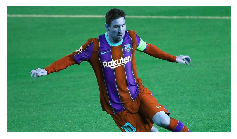

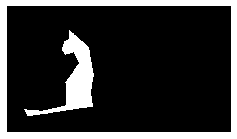

In [ ]:
### Main Block: ###

# read image
img_name = 'messi'
img_path = '/content/Part2_GraphCut/messi.jpg'
img = cv2.imread(img_path)
# read image_mask
poly = scipy.io.loadmat('/content/Part2_GraphCut/cat_poly.mat')['poly']
img_mask = poly2mask(poly[:,1], poly[:,0], (img.shape[0],img.shape[1]))
show_image(img)
show_image(img_mask)

In [ ]:
# 1. Fit Gaussian mixture model for foreground regions.

# Generate image (fg_image) with background masked using img_mask
fg_image = mask_for_fg(img, img_mask)
gmm_fg, fg_gmm_labels,fg_prob =fore_gaussian_model(fg_image)


# 2. Fit Gaussian mixture model for background regions.
# Generate image (fg_image) with foreground masked using img_mask
bg_image = mask_for_bg(img, img_mask)
gmm_bg, bg_gmm_labels, bg_prob = back_gaussian_model(bg_image)



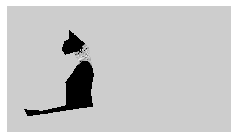

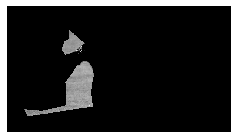

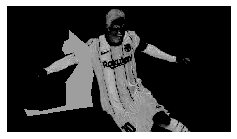

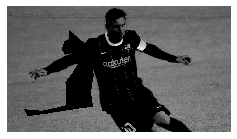

In [ ]:
# 3. Compute and visualize the foreground cost and background cost as an image.
# Foreground label cost: -log Pr[Image | foreground model]
# Foreground label cost: -log Pr[Image | background model]

visualize_likelihood_map(fg_prob,bg_prob)


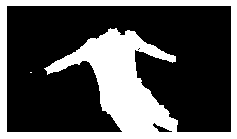

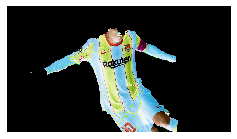

In [ ]:
# 4. Run grabcut algorithm.
bboxes = {'cat':(80,80,320,250), 'dog':(50,300,600,300), 'plane': (180,80,250,800), 'messi':(10,80,600,500), 'bird':(100,100,350,250)}
bbox = bboxes[img_name]
(grabcut_mask, bgModel, fgModel) = run_grabcut(img, bbox)
show_image(grabcut_mask)
masked_img = img*grabcut_mask[:,:,np.newaxis]
show_image(masked_img)


### Write-up (35 points)

- a) [5 points] Explain your foreground and background likelihood function.
- b) [10 points] Your foreground and background likelihood map. 

Display P(foreground|pixel) as an intensity map (bright = confident foreground).
- c) [15 points] Implement grabcut segmentation using cv2 package and draw insights on how the segmentation performs on different sample images (hard v/s easy).
- d) [5 points] Try grabcut algorithm with different "iterCount" to see if results improve in certain cases.

# Write-up for Q2:

###a) To get background and foreground likelihood used GMMM function from sklearn library. The following code used to get the gmm_model $gmm_model=gmm(n_components=2,covariance_type='tied',random_state=1).fit((img[img_mask==1]/255))$ here image mask's can be checked. For foreground $==1$ is checked and for back ground $==0$ is checked. 

###b) These are th results from $visualixe_likelihood()$ funtion
![picture](https://drive.google.com/uc?id=1qmgY-DrWqVwAJSu8RzixpftqWGhyUWE_)

### c) In Grabcut we want to extract foreground in images. Using the cv2 function cv2.grabCut() first we initialize a bounding boxes in ours case we used cat, dog , plane messi and bird. We also defined the size of bounding boxes in $bboxes$. We give the function run_grabCut the following parameters: (grabcut_mask, bgModel, fgModel). This gives us following results for cat:

![picture](https://drive.google.com/uc?id=19-I-JUKnON1VnFwa1P86WgEWPYLNirFf)

Here the algorithm works poorly since the surrounding region has high contrast and difference in neighbouring pixel was such that it created such cut. 

In case of messi's image:

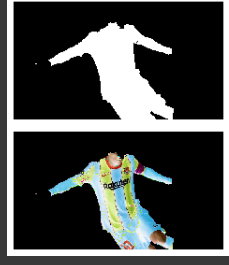

This is how the grabcut came out. This is due to the surrounding region to messi was having greater difference in pixel intensity and due to this difference it was a better cut than the cat

### d) I did not see significant changes when I ran for different itercounts. (I tried 1,2,4)